# Projeto 3 — Pricing & Margin Optimization

## Electronics e Personal Care

### Objetivo

Este projeto parte dos resultados dos Projetos 1 e 2 para responder uma nova pergunta de negócio:

> **Qual nível de desconto maximiza o lucro esperado, considerando a resposta prevista da demanda?**

Nos projetos anteriores:

- o **Projeto 1** estimou demanda e investigou fatores comerciais;
- o **Projeto 2** otimizou a alocação de capital entre categorias;
- agora o **Projeto 3** transforma o desconto em uma variável de decisão.

A análise compara, para cada nível de desconto:

- unidades previstas;
- preço efetivo;
- receita;
- custo;
- lucro bruto;
- margem bruta.

Também identificamos separadamente o desconto que maximiza:

1. volume;
2. receita;
3. lucro;
4. margem.

> **Importante:** a resposta prevista ao desconto é baseada no modelo comercial e deve ser interpretada como simulação preditiva, não como efeito causal comprovado.


## 1. Bibliotecas e leitura da base tratada


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

ARQUIVO = "retail_sales_cleaned_project1.csv"

df = pd.read_csv(
    ARQUIVO,
    parse_dates=["date"]
)

categorias = [
    "Electronics",
    "Personal Care"
]

base = (
    df[df["category"].isin(categorias)]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Linhas selecionadas: {len(base):,}")
print(f"Período: {base['date'].min().date()} a {base['date'].max().date()}")

display(base.head())


Linhas selecionadas: 1,097
Período: 2024-01-01 a 2024-12-31


,store_id,product_id,date,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week,day_of_week_original,weekday_was_correct,year,month,month_name,quarter,week,is_weekend,gross_revenue,effective_price_est,net_sales_est
0,49,1341,2024-01-01,Personal Care,389,Yes,10,14,373,Monday,Thursday,False,2024,1,January,1,1,False,5446,350.10,"4,901.40"
1,39,1950,2024-01-02,Electronics,996,Yes,0,40,129,Tuesday,Saturday,False,2024,1,January,1,1,False,39840,996.00,"39,840.00"
2,36,1206,2024-01-02,Electronics,547,Yes,5,24,348,Tuesday,Sunday,False,2024,1,January,1,1,False,13128,519.65,"12,471.60"
3,24,1886,2024-01-02,Personal Care,1386,Yes,5,10,429,Tuesday,Wednesday,False,2024,1,January,1,1,False,13860,"1,316.70","13,167.00"
4,43,1080,2024-01-03,Electronics,671,Yes,0,34,477,Wednesday,Sunday,False,2024,1,January,1,1,False,22814,671.00,"22,814.00"


## 2. Preparação das features

Mantemos a mesma lógica do modelo comercial utilizado anteriormente.

### Variáveis comerciais
- preço-base;
- desconto;
- estoque;
- promoção.

### Variáveis de contexto
- categoria;
- loja;
- dia da semana;
- fim de semana;
- mês em representação cíclica.

O alvo continua sendo `units_sold`.


In [2]:
model_data = base.copy()

model_data["month_num"] = (
    model_data["date"].dt.month
)

model_data["day_name"] = (
    model_data["date"].dt.day_name()
)

model_data["is_weekend_model"] = (
    model_data["date"].dt.dayofweek >= 5
).astype(int)

model_data["month_sin"] = np.sin(
    2 * np.pi
    * model_data["month_num"]
    / 12
)

model_data["month_cos"] = np.cos(
    2 * np.pi
    * model_data["month_num"]
    / 12
)

features = [
    "price",
    "discount_percent",
    "inventory_level",
    "promotion_active",
    "category",
    "store_id",
    "day_name",
    "is_weekend_model",
    "month_sin",
    "month_cos"
]

target = "units_sold"

X = model_data[features].copy()
y = model_data[target].copy()


## 3. Divisão temporal treino/teste

Mantemos as últimas 8 semanas como período de teste.

O objetivo é selecionar novamente o modelo comercial com melhor desempenho antes de utilizá-lo na simulação de pricing.


In [3]:
cutoff_date = (
    model_data["date"].max()
    - pd.Timedelta(weeks=8)
)

train_mask = (
    model_data["date"] <= cutoff_date
)

test_mask = (
    model_data["date"] > cutoff_date
)

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print(f"Data de corte: {cutoff_date.date()}")
print(f"Treino: {len(X_train):,}")
print(f"Teste: {len(X_test):,}")


Data de corte: 2024-11-05
Treino: 907
Teste: 190


## 4. Modelos comerciais

Comparamos novamente:

- Ridge Regression;
- Random Forest.

O modelo vencedor será utilizado para estimar a resposta da demanda aos diferentes níveis de desconto.


In [4]:
numeric_features = [
    "price",
    "discount_percent",
    "inventory_level",
    "is_weekend_model",
    "month_sin",
    "month_cos"
]

categorical_features = [
    "promotion_active",
    "category",
    "store_id",
    "day_name"
]

preprocessor_linear = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

ridge_model = Pipeline([
    ("preprocessor", preprocessor_linear),
    ("model", Ridge(alpha=1.0))
])

rf_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    (
        "model",
        RandomForestRegressor(
            n_estimators=400,
            max_depth=8,
            min_samples_leaf=4,
            random_state=42,
            n_jobs=-1
        )
    )
])

ridge_model.fit(
    X_train,
    y_train
)

rf_model.fit(
    X_train,
    y_train
)

pred_ridge = ridge_model.predict(X_test)
pred_rf = rf_model.predict(X_test)


In [5]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        )
        * 100
    )


def bias(y_true, y_pred):
    return np.mean(
        np.asarray(y_pred)
        - np.asarray(y_true)
    )


def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),
        "MAPE": mape(
            y_true,
            y_pred
        ),
        "Bias": bias(
            y_true,
            y_pred
        )
    }


model_results = pd.DataFrame([
    {
        "Model": "Ridge",
        **metrics(
            y_test,
            pred_ridge
        )
    },
    {
        "Model": "Random Forest",
        **metrics(
            y_test,
            pred_rf
        )
    }
])

display(model_results)


,Model,MAE,RMSE,MAPE,Bias
0,Ridge,10.07,12.15,58.33,-0.13
1,Random Forest,9.78,11.68,55.17,-0.70


In [6]:
best_model_name = (
    model_results
    .sort_values("MAPE")
    .iloc[0]["Model"]
)

best_model = (
    ridge_model
    if best_model_name == "Ridge"
    else rf_model
)

print("Modelo selecionado:", best_model_name)


Modelo selecionado: Random Forest


# 5. Construção de uma estrutura futura comparável ao histórico

Para comparar descontos de forma justa, todos os níveis de desconto devem usar **a mesma estrutura futura**.

Por isso:

1. calculamos a quantidade mediana de observações por semana e categoria nas últimas 8 semanas;
2. amostramos uma única vez lojas e dias da semana do período recente;
3. congelamos essa estrutura;
4. copiamos exatamente as mesmas observações para cada nível de desconto.

Assim, a diferença entre os cenários não será causada por alterações aleatórias na quantidade de registros, lojas ou dias da semana.


In [7]:
RECENT_WEEKS = 8
FORECAST_WEEKS = 8
RANDOM_STATE = 42

recent_cutoff = (
    base["date"].max()
    - pd.Timedelta(weeks=RECENT_WEEKS)
)

recent = (
    base[base["date"] > recent_cutoff]
    .copy()
)

recent_weekly_records = (
    recent.set_index("date")
          .groupby("category")
          .resample("W-SUN")
          .size()
          .rename("records")
          .reset_index()
)

records_reference = (
    recent_weekly_records
    .groupby("category")["records"]
    .median()
    .round()
    .astype(int)
)

display(
    records_reference
    .to_frame("records_per_week")
)


,records_per_week
category,
Electronics,9
Personal Care,13


In [8]:
commercial_reference = (
    recent.groupby("category")
          .agg(
              median_price=(
                  "price",
                  "median"
              ),
              median_inventory=(
                  "inventory_level",
                  "median"
              ),
              promotion_rate=(
                  "promotion_active",
                  lambda x: (
                      x == "Yes"
                  ).mean()
              )
          )
)

display(commercial_reference)


,median_price,median_inventory,promotion_rate
category,,,
Electronics,"1,284.00",237.50,0.52
Personal Care,"1,670.50",243.50,0.42


In [9]:
last_date = base["date"].max()

first_future_sunday = (
    last_date
    + pd.offsets.Week(
        weekday=6
    )
)

future_week_ends = pd.date_range(
    start=first_future_sunday,
    periods=FORECAST_WEEKS,
    freq="W-SUN"
)

future_week_ends


DatetimeIndex(['2025-01-05', '2025-01-12', '2025-01-19', '2025-01-26',
               '2025-02-02', '2025-02-09', '2025-02-16', '2025-02-23'],
              dtype='datetime64[us]', freq='W-SUN')

In [10]:
def build_future_template(
    recent_data,
    records_reference,
    commercial_reference,
    random_state=42
):
    rng = np.random.default_rng(
        random_state
    )

    rows = []

    for categoria in categorias:

        cat_recent = (
            recent_data[
                recent_data["category"]
                == categoria
            ]
            .copy()
        )

        n_records = int(
            records_reference.loc[
                categoria
            ]
        )

        ref = (
            commercial_reference
            .loc[categoria]
        )

        for week_number, week_end in enumerate(
            future_week_ends,
            start=1
        ):

            sampled = cat_recent.sample(
                n=n_records,
                replace=True,
                random_state=(
                    random_state
                    + week_number
                    + (
                        0
                        if categoria
                        == categorias[0]
                        else 1000
                    )
                )
            ).copy()

            sampled_day_num = (
                sampled["date"]
                .dt.dayofweek
                .to_numpy()
            )

            week_start = (
                week_end
                - pd.Timedelta(days=6)
            )

            future_dates = [
                week_start
                + pd.Timedelta(
                    days=int(day_num)
                )
                for day_num
                in sampled_day_num
            ]

            promo_flags = (
                rng.random(
                    n_records
                )
                < ref["promotion_rate"]
            )

            for i in range(n_records):

                rows.append({
                    "forecast_week": week_end,
                    "date": future_dates[i],
                    "category": categoria,
                    "store_id": (
                        sampled.iloc[i][
                            "store_id"
                        ]
                    ),
                    "price": (
                        ref["median_price"]
                    ),
                    "inventory_level": (
                        ref[
                            "median_inventory"
                        ]
                    ),
                    "promotion_active": (
                        "Yes"
                        if promo_flags[i]
                        else "No"
                    )
                })

    future = pd.DataFrame(rows)

    future["month_num"] = (
        future["date"].dt.month
    )

    future["day_name"] = (
        future["date"].dt.day_name()
    )

    future["is_weekend_model"] = (
        future["date"].dt.dayofweek
        >= 5
    ).astype(int)

    future["month_sin"] = np.sin(
        2 * np.pi
        * future["month_num"]
        / 12
    )

    future["month_cos"] = np.cos(
        2 * np.pi
        * future["month_num"]
        / 12
    )

    return future


future_template = (
    build_future_template(
        recent_data=recent,
        records_reference=records_reference,
        commercial_reference=commercial_reference,
        random_state=RANDOM_STATE
    )
)

display(future_template.head())

print(
    "Total de observações na estrutura futura:",
    len(future_template)
)


,forecast_week,date,category,store_id,price,inventory_level,promotion_active,month_num,day_name,is_weekend_model,month_sin,month_cos
0,2025-01-05,2025-01-01,Electronics,46,"1,284.00",237.50,No,1,Wednesday,0,0.50,0.87
1,2025-01-05,2025-01-05,Electronics,2,"1,284.00",237.50,Yes,1,Sunday,1,0.50,0.87
2,2025-01-05,2024-12-31,Electronics,36,"1,284.00",237.50,No,12,Tuesday,0,-0.00,1.00
3,2025-01-05,2025-01-03,Electronics,11,"1,284.00",237.50,No,1,Friday,0,0.50,0.87
4,2025-01-05,2025-01-04,Electronics,13,"1,284.00",237.50,Yes,1,Saturday,1,0.50,0.87


Total de observações na estrutura futura: 176


# 6. Premissas de custo

Mantemos as mesmas premissas financeiras utilizadas no Projeto 1:

- Electronics: custo estimado = 65% do preço-base;
- Personal Care: custo estimado = 55% do preço-base.

Esses custos não vieram da base original e continuam sendo tratados como premissas explícitas.


In [11]:
cost_assumptions = pd.DataFrame({
    "category": [
        "Electronics",
        "Personal Care"
    ],
    "cost_pct_of_list_price": [
        0.65,
        0.55
    ]
})

display(cost_assumptions)


,category,cost_pct_of_list_price
0,Electronics,0.65
1,Personal Care,0.55


# 7. Curva de sensibilidade de desconto

Vamos testar descontos de **0% a 30%**, em intervalos de 1 ponto percentual.

Para cada desconto:

1. aplicamos o valor às mesmas observações futuras;
2. estimamos `units_sold` com o modelo comercial;
3. calculamos preço efetivo;
4. calculamos receita;
5. calculamos custo;
6. calculamos lucro bruto;
7. calculamos margem bruta.

Assim podemos comparar diretamente os trade-offs entre volume e rentabilidade.


In [12]:
DISCOUNT_RANGE = range(
    0,
    31,
    1
)

pricing_rows = []

for discount in DISCOUNT_RANGE:

    scenario = (
        future_template
        .copy()
    )

    scenario[
        "discount_percent"
    ] = discount

    X_future = (
        scenario[features]
    )

    scenario[
        "forecast_units"
    ] = np.maximum(
        best_model.predict(
            X_future
        ),
        0
    )

    scenario = (
        scenario.merge(
            cost_assumptions,
            on="category",
            how="left"
        )
    )

    scenario[
        "effective_price"
    ] = (
        scenario["price"]
        * (
            1
            - scenario[
                "discount_percent"
            ]
            / 100
        )
    )

    scenario[
        "unit_cost_est"
    ] = (
        scenario["price"]
        * scenario[
            "cost_pct_of_list_price"
        ]
    )

    scenario[
        "revenue_est"
    ] = (
        scenario[
            "forecast_units"
        ]
        * scenario[
            "effective_price"
        ]
    )

    scenario[
        "cost_est"
    ] = (
        scenario[
            "forecast_units"
        ]
        * scenario[
            "unit_cost_est"
        ]
    )

    scenario[
        "gross_profit_est"
    ] = (
        scenario[
            "revenue_est"
        ]
        - scenario[
            "cost_est"
        ]
    )

    pricing_rows.append(
        scenario
    )


pricing_detailed = pd.concat(
    pricing_rows,
    ignore_index=True
)

pricing_curve = (
    pricing_detailed
    .groupby(
        [
            "category",
            "discount_percent"
        ],
        as_index=False
    )
    .agg(
        forecast_units=(
            "forecast_units",
            "sum"
        ),
        avg_list_price=(
            "price",
            "mean"
        ),
        effective_price=(
            "effective_price",
            "mean"
        ),
        revenue_est=(
            "revenue_est",
            "sum"
        ),
        cost_est=(
            "cost_est",
            "sum"
        ),
        gross_profit_est=(
            "gross_profit_est",
            "sum"
        )
    )
)

pricing_curve[
    "gross_margin_pct"
] = np.where(
    pricing_curve[
        "revenue_est"
    ] != 0,
    (
        pricing_curve[
            "gross_profit_est"
        ]
        / pricing_curve[
            "revenue_est"
        ]
        * 100
    ),
    np.nan
)

display(pricing_curve.head(20))


,category,discount_percent,forecast_units,avg_list_price,effective_price,revenue_est,cost_est,gross_profit_est,gross_margin_pct
0,Electronics,0,"1,806.96","1,284.00","1,284.00","2,320,132.99","1,508,086.45","812,046.55",35.00
1,Electronics,1,"1,806.96","1,284.00","1,271.16","2,296,931.66","1,508,086.45","788,845.22",34.34
2,Electronics,2,"1,806.96","1,284.00","1,258.32","2,273,730.33","1,508,086.45","765,643.89",33.67
3,Electronics,3,"1,800.46","1,284.00","1,245.48","2,242,441.90","1,502,667.25","739,774.65",32.99
4,Electronics,4,"1,800.46","1,284.00","1,232.64","2,219,323.94","1,502,667.25","716,656.69",32.29
5,Electronics,5,"1,800.46","1,284.00","1,219.80","2,196,205.99","1,502,667.25","693,538.73",31.58
6,Electronics,6,"1,800.44","1,284.00","1,206.96","2,173,054.03","1,502,643.75","670,410.29",30.85
7,Electronics,7,"1,800.44","1,284.00","1,194.12","2,149,936.44","1,502,643.75","647,292.69",30.11
8,Electronics,8,"1,850.28","1,284.00","1,181.28","2,185,704.15","1,544,247.50","641,456.65",29.35
9,Electronics,9,"1,850.28","1,284.00","1,168.44","2,161,946.49","1,544,247.50","617,699.00",28.57


## 8. Curva: desconto × volume


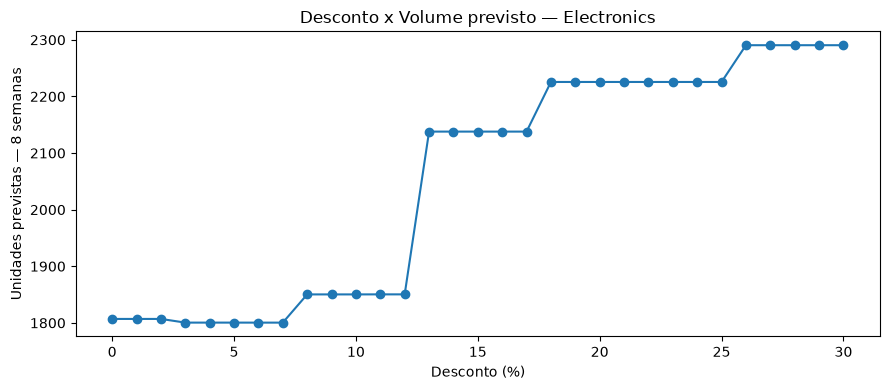

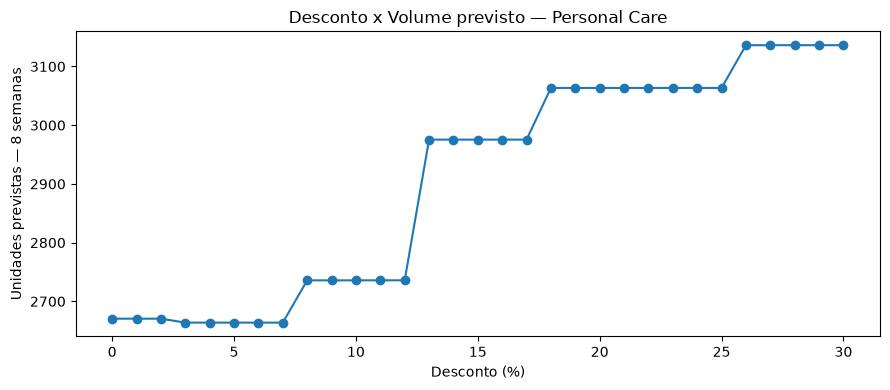

In [13]:
for categoria in categorias:

    temp = (
        pricing_curve[
            pricing_curve["category"]
            == categoria
        ]
        .copy()
    )

    plt.figure(
        figsize=(9, 4)
    )

    plt.plot(
        temp["discount_percent"],
        temp["forecast_units"],
        marker="o"
    )

    plt.title(
        f"Desconto x Volume previsto — {categoria}"
    )

    plt.xlabel(
        "Desconto (%)"
    )

    plt.ylabel(
        "Unidades previstas — 8 semanas"
    )

    plt.tight_layout()
    plt.show()


## 9. Curva: desconto × receita


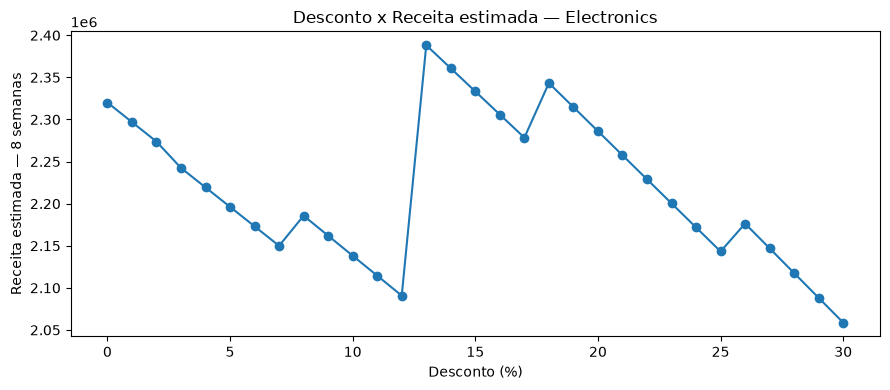

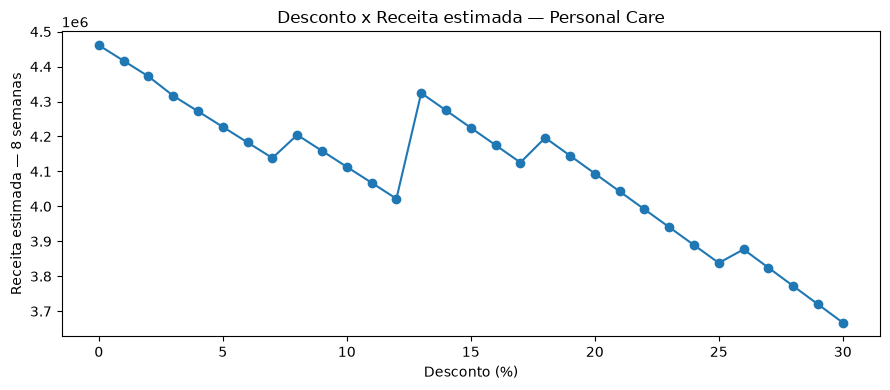

In [14]:
for categoria in categorias:

    temp = (
        pricing_curve[
            pricing_curve["category"]
            == categoria
        ]
        .copy()
    )

    plt.figure(
        figsize=(9, 4)
    )

    plt.plot(
        temp["discount_percent"],
        temp["revenue_est"],
        marker="o"
    )

    plt.title(
        f"Desconto x Receita estimada — {categoria}"
    )

    plt.xlabel(
        "Desconto (%)"
    )

    plt.ylabel(
        "Receita estimada — 8 semanas"
    )

    plt.tight_layout()
    plt.show()


## 10. Curva: desconto × lucro bruto


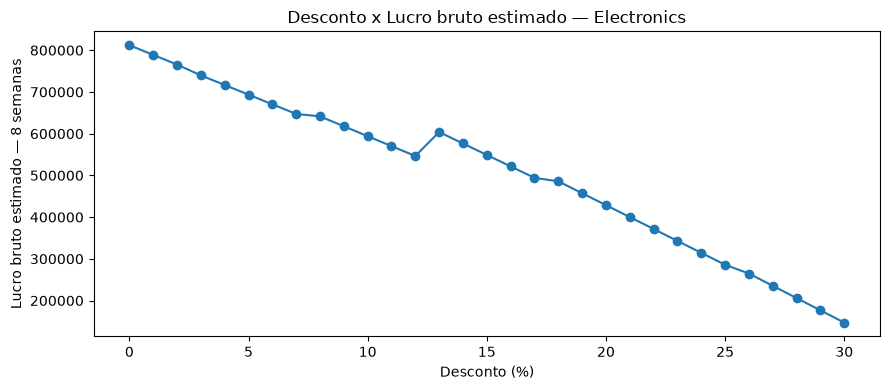

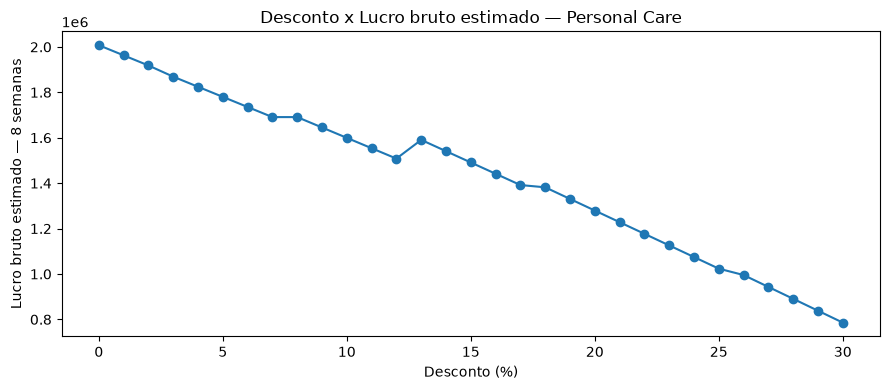

In [15]:
for categoria in categorias:

    temp = (
        pricing_curve[
            pricing_curve["category"]
            == categoria
        ]
        .copy()
    )

    plt.figure(
        figsize=(9, 4)
    )

    plt.plot(
        temp["discount_percent"],
        temp["gross_profit_est"],
        marker="o"
    )

    plt.title(
        f"Desconto x Lucro bruto estimado — {categoria}"
    )

    plt.xlabel(
        "Desconto (%)"
    )

    plt.ylabel(
        "Lucro bruto estimado — 8 semanas"
    )

    plt.tight_layout()
    plt.show()


## 11. Curva: desconto × margem


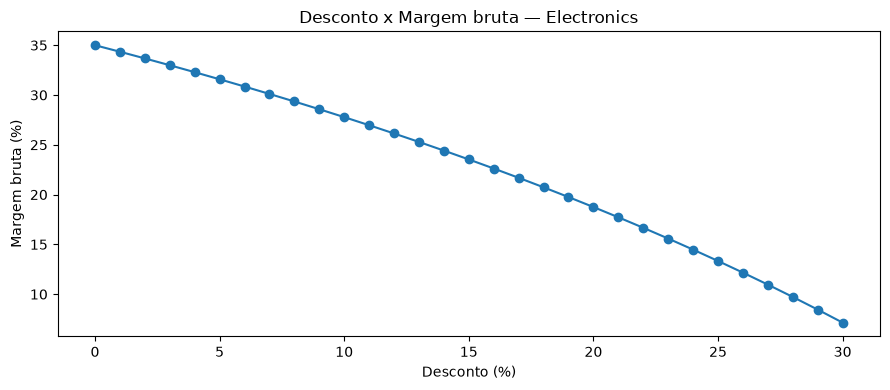

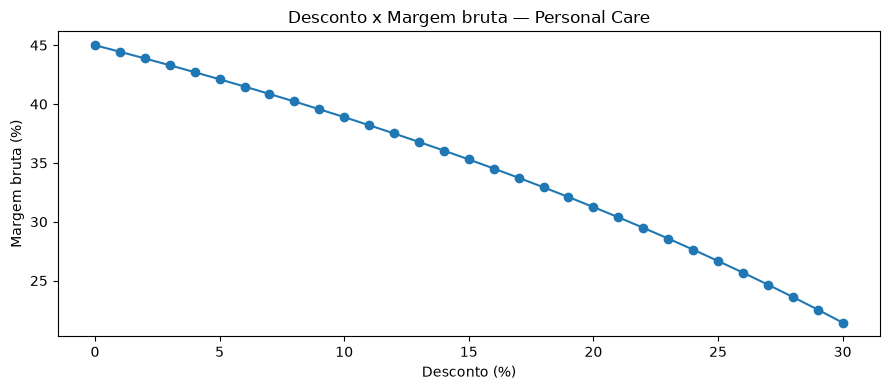

In [16]:
for categoria in categorias:

    temp = (
        pricing_curve[
            pricing_curve["category"]
            == categoria
        ]
        .copy()
    )

    plt.figure(
        figsize=(9, 4)
    )

    plt.plot(
        temp["discount_percent"],
        temp["gross_margin_pct"],
        marker="o"
    )

    plt.title(
        f"Desconto x Margem bruta — {categoria}"
    )

    plt.xlabel(
        "Desconto (%)"
    )

    plt.ylabel(
        "Margem bruta (%)"
    )

    plt.tight_layout()
    plt.show()


# 12. Identificação automática dos pontos ótimos

Agora identificamos separadamente:

- maior volume;
- maior receita;
- maior lucro;
- maior margem.

Isso permite demonstrar que cada objetivo pode levar a uma decisão diferente.


In [17]:
optimal_rows = []

for categoria in categorias:

    temp = (
        pricing_curve[
            pricing_curve["category"]
            == categoria
        ]
        .copy()
    )

    objectives = {
        "Max Volume": (
            "forecast_units"
        ),
        "Max Revenue": (
            "revenue_est"
        ),
        "Max Profit": (
            "gross_profit_est"
        ),
        "Max Margin": (
            "gross_margin_pct"
        )
    }

    for objective_name, metric in objectives.items():

        best_row = (
            temp.loc[
                temp[metric].idxmax()
            ]
        )

        optimal_rows.append({
            "category": categoria,
            "objective": objective_name,
            "optimal_discount": (
                best_row[
                    "discount_percent"
                ]
            ),
            "forecast_units": (
                best_row[
                    "forecast_units"
                ]
            ),
            "effective_price": (
                best_row[
                    "effective_price"
                ]
            ),
            "revenue_est": (
                best_row[
                    "revenue_est"
                ]
            ),
            "gross_profit_est": (
                best_row[
                    "gross_profit_est"
                ]
            ),
            "gross_margin_pct": (
                best_row[
                    "gross_margin_pct"
                ]
            )
        })


optimal_points = pd.DataFrame(
    optimal_rows
)

display(optimal_points)


,category,objective,optimal_discount,forecast_units,effective_price,revenue_est,gross_profit_est,gross_margin_pct
0,Electronics,Max Volume,26,"2,290.51",950.16,"2,176,352.94","264,691.57",12.16
1,Electronics,Max Revenue,13,"2,137.90","1,117.08","2,388,201.60","603,913.05",25.29
2,Electronics,Max Profit,0,"1,806.96","1,284.00","2,320,132.99","812,046.55",35.00
3,Electronics,Max Margin,0,"1,806.96","1,284.00","2,320,132.99","812,046.55",35.00
4,Personal Care,Max Volume,27,"3,136.20","1,219.46","3,824,492.12","943,025.45",24.66
5,Personal Care,Max Revenue,0,"2,670.50","1,670.50","4,461,078.22","2,007,485.20",45.00
6,Personal Care,Max Profit,0,"2,670.50","1,670.50","4,461,078.22","2,007,485.20",45.00
7,Personal Care,Max Margin,0,"2,670.50","1,670.50","4,461,078.22","2,007,485.20",45.00


# 13. Trade-off entre volume e lucro

O objetivo desta etapa é evidenciar uma diferença fundamental em pricing:

> **O desconto que maximiza volume não precisa maximizar lucro.**

A tabela abaixo compara diretamente esses dois objetivos.


In [18]:
tradeoff = (
    optimal_points[
        optimal_points[
            "objective"
        ].isin([
            "Max Volume",
            "Max Profit"
        ])
    ]
    .copy()
)

display(tradeoff)


,category,objective,optimal_discount,forecast_units,effective_price,revenue_est,gross_profit_est,gross_margin_pct
0,Electronics,Max Volume,26,"2,290.51",950.16,"2,176,352.94","264,691.57",12.16
2,Electronics,Max Profit,0,"1,806.96","1,284.00","2,320,132.99","812,046.55",35.00
4,Personal Care,Max Volume,27,"3,136.20","1,219.46","3,824,492.12","943,025.45",24.66
6,Personal Care,Max Profit,0,"2,670.50","1,670.50","4,461,078.22","2,007,485.20",45.00


# 14. Elasticidade aproximada entre pontos da curva

Para enriquecer a interpretação, calculamos uma elasticidade aproximada entre pontos consecutivos:

\[
Elasticidade =
\frac{\%\Delta Q}
{\%\Delta P}
\]

onde:

- `Q` = unidades previstas;
- `P` = preço efetivo.

Como a curva vem de um modelo preditivo e não de um experimento causal, esta medida deve ser entendida como **elasticidade implícita no modelo**, não como elasticidade causal de mercado.


In [19]:
elasticity_rows = []

for categoria in categorias:

    temp = (
        pricing_curve[
            pricing_curve["category"]
            == categoria
        ]
        .sort_values(
            "discount_percent"
        )
        .copy()
    )

    temp[
        "pct_change_units"
    ] = (
        temp["forecast_units"]
        .pct_change()
    )

    temp[
        "pct_change_price"
    ] = (
        temp["effective_price"]
        .pct_change()
    )

    temp[
        "model_implied_elasticity"
    ] = (
        temp[
            "pct_change_units"
        ]
        / temp[
            "pct_change_price"
        ]
    )

    elasticity_rows.append(
        temp
    )


elasticity_curve = pd.concat(
    elasticity_rows,
    ignore_index=True
)

display(
    elasticity_curve[[
        "category",
        "discount_percent",
        "effective_price",
        "forecast_units",
        "model_implied_elasticity"
    ]].head(20)
)


,category,discount_percent,effective_price,forecast_units,model_implied_elasticity
0,Electronics,0,"1,284.00","1,806.96",NaN
1,Electronics,1,"1,271.16","1,806.96",-0.00
2,Electronics,2,"1,258.32","1,806.96",0.00
3,Electronics,3,"1,245.48","1,800.46",0.35
4,Electronics,4,"1,232.64","1,800.46",-0.00
5,Electronics,5,"1,219.80","1,800.46",-0.00
6,Electronics,6,"1,206.96","1,800.44",0.00
7,Electronics,7,"1,194.12","1,800.44",0.00
8,Electronics,8,"1,181.28","1,850.28",-2.57
9,Electronics,9,"1,168.44","1,850.28",-0.00


# 15. Conclusão desta fase

Esta etapa transforma o desconto em uma variável de decisão e conecta diretamente:

\[
Desconto
\rightarrow
Demanda
\rightarrow
Receita
\rightarrow
Lucro
\rightarrow
Margem
\]

O resultado mais importante não é necessariamente encontrar um desconto positivo.

Se o ponto de maior lucro estiver próximo de 0%, isso significa que, **dentro da resposta de demanda aprendida pelo modelo e das premissas de custo utilizadas**, o ganho de volume provocado pelos descontos não é suficiente para compensar a redução de contribuição por unidade.

Da mesma forma, se um desconto maior maximizar volume mas reduzir lucro, o projeto demonstrará claramente a diferença entre:

- estratégia orientada a volume;
- estratégia orientada a faturamento;
- estratégia orientada a rentabilidade.

A próxima etapa poderá transformar essa curva em uma **otimização automática de pricing**, incluindo restrições de margem e limites comerciais.


## 16. Exportação


In [20]:
model_results.to_csv(
    "pricing_model_results.csv",
    index=False,
    encoding="utf-8-sig"
)

pricing_curve.to_csv(
    "pricing_discount_sensitivity_curve.csv",
    index=False,
    encoding="utf-8-sig"
)

optimal_points.to_csv(
    "pricing_optimal_points.csv",
    index=False,
    encoding="utf-8-sig"
)

elasticity_curve.to_csv(
    "pricing_model_implied_elasticity.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos gerados:")
print("- pricing_model_results.csv")
print("- pricing_discount_sensitivity_curve.csv")
print("- pricing_optimal_points.csv")
print("- pricing_model_implied_elasticity.csv")


Arquivos gerados:
- pricing_model_results.csv
- pricing_discount_sensitivity_curve.csv
- pricing_optimal_points.csv
- pricing_model_implied_elasticity.csv
